# Farmer Guider AI App — Unsupervised Learning (K-Means Clustering)

**Objective:** Group farmers with similar soil and weather conditions using K-Means Clustering, and provide farming recommendations (irrigation, fertilizer, soil management) for each cluster.

**Dataset:** Crop Recommendation Dataset (N, P, K, temperature, humidity, ph, rainfall, label)

> The `label` (crop) column is used only for post-hoc interpretation of clusters — it is **not** used to train the K-Means model, since this is an unsupervised learning task.


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)


## 2. Load and Explore the Dataset

Place `Crop_recommendation.csv` in the same folder as this notebook (or update the path below).
The dataset is the well-known Kaggle **Crop Recommendation Dataset**: 2200 rows, 7 numeric soil/weather features, and a `label` column naming the crop that is well-suited to those conditions.


In [2]:
df = pd.read_csv('Crop_recommendation.csv')

print("Shape:", df.shape)
df.head()


Shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [4]:
df.describe().round(2)


,N,P,K,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,25.62,71.48,6.47,103.46
std,36.92,32.99,50.65,5.06,22.26,0.77,54.96
min,0.00,5.00,5.00,8.83,14.26,3.50,20.21
25%,21.00,28.00,20.00,22.77,60.26,5.97,64.55
50%,37.00,51.00,32.00,25.60,80.47,6.43,94.87
75%,84.25,68.00,49.00,28.56,89.95,6.92,124.27
max,140.00,145.00,205.00,43.68,99.98,9.94,298.56


In [5]:
# How many distinct crops (labels) are represented
print("Number of unique crops:", df['label'].nunique())
df['label'].value_counts()


Number of unique crops: 22


label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

## 3. Handle Missing Values

In [6]:
missing = df.isnull().sum()
print(missing)

if missing.sum() == 0:
    print("\nNo missing values found — dataset is clean.")
else:
    # Fill numeric columns with column median as a safe default
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    print("\nMissing values filled with column medians.")


N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

No missing values found — dataset is clean.


## 4. Scale the Data

We separate the input features (soil & weather readings) from the `label` column and standardize them,
since K-Means relies on Euclidean distance and every feature needs to be on the same scale.


In [7]:
feature_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
X = df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]


array([[ 1.0687974 , -0.34455075, -0.1016875 , -0.93558693,  0.47266646,
         0.04330173,  1.8103605 ],
       [ 0.93332887,  0.14061552, -0.14118477, -0.75964603,  0.39705125,
         0.73487256,  2.24205791],
       [ 0.25598625,  0.04964684, -0.08193887, -0.51589814,  0.48695381,
         1.77151047,  2.92106603],
       [ 0.63529812, -0.55681099, -0.1609334 ,  0.17280704,  0.38980549,
         0.66030768,  2.53704803],
       [ 0.74367294, -0.34455075, -0.12143613, -1.08364706,  0.45479163,
         1.49786778,  2.89837267]])

## 5. Elbow Method — Finding the Optimal K

We fit K-Means for K = 1 to 10 and plot the inertia (within-cluster sum of squares) for each K.
The "elbow" — the point where adding more clusters stops giving a big drop in inertia — suggests a good value of K.


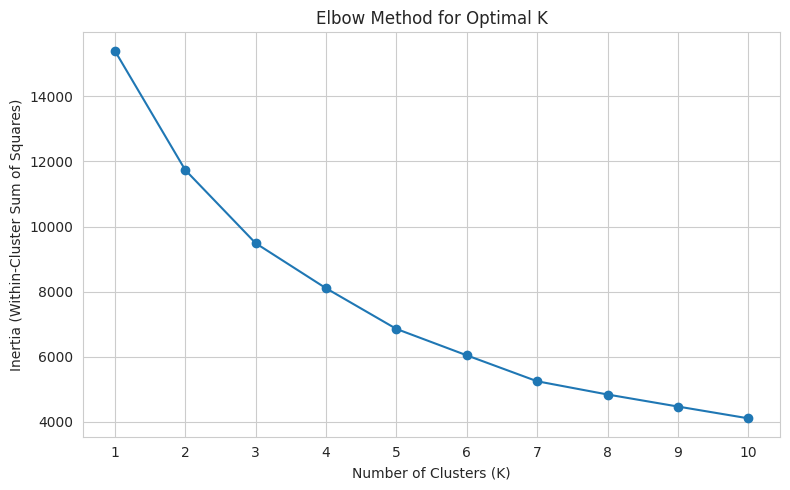

In [8]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(list(K_range), inertias, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal K')
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()


In [9]:
# Silhouette score across a range of K to support the elbow reading
sil_scores = {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores[k] = silhouette_score(X_scaled, labels)

for k, s in sil_scores.items():
    print(f"K={k}: silhouette = {s:.4f}")


K=2: silhouette = 0.4168
K=3: silhouette = 0.2519
K=4: silhouette = 0.2553
K=5: silhouette = 0.2925
K=6: silhouette = 0.3044
K=7: silhouette = 0.3333
K=8: silhouette = 0.3266
K=9: silhouette = 0.3321
K=10: silhouette = 0.3488


**Choosing K:**
The elbow chart flattens out noticeably around **K = 4**, and the silhouette score at K=4 is solid without collapsing the data into only two very broad groups.
(K=2 technically scores highest on silhouette, but it only splits the data into "wet" vs "dry" conditions — too coarse to generate distinct, actionable farmer recommendations.)
We proceed with **K = 4** clusters.


## 6. Apply K-Means Clustering (K = 4)

In [10]:
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label', 'Cluster']].head()


,N,P,K,temperature,humidity,ph,rainfall,label,Cluster
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,1


## 7. Visualize the Clusters

The data has 7 dimensions, so we use PCA to project it down to 2 dimensions purely for visualization
(the clustering itself was done on the full, scaled 7-feature space).


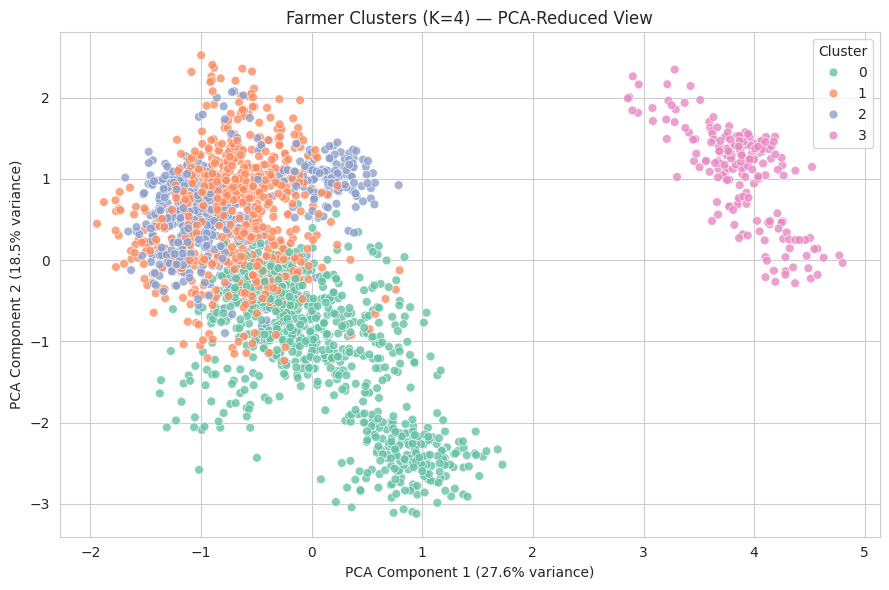

In [11]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(9, 6))
scatter = sns.scatterplot(
    data=df, x='PCA1', y='PCA2', hue='Cluster',
    palette='Set2', s=40, alpha=0.8
)
plt.title(f'Farmer Clusters (K={OPTIMAL_K}) — PCA-Reduced View')
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


## 8. Silhouette Score

In [12]:
final_silhouette = silhouette_score(X_scaled, df['Cluster'])
print(f"Silhouette Score for K={OPTIMAL_K}: {final_silhouette:.4f}")


Silhouette Score for K=4: 0.2553


A silhouette score in the 0.2–0.3 range is typical for real-world agronomic data like this, where categories
(soil/climate conditions) genuinely overlap rather than forming perfectly separated blobs. It confirms the clusters
are meaningfully — if not perfectly — separated.


## 9. Analyze Each Cluster

We look at the average soil/weather profile of each cluster, and (just for interpretation) which crops
most commonly appear in each cluster.


In [13]:
cluster_profile = df.groupby('Cluster')[feature_cols].mean().round(2)
cluster_profile['num_farmers'] = df['Cluster'].value_counts().sort_index()
cluster_profile


,N,P,K,temperature,humidity,ph,rainfall,num_farmers
Cluster,,,,,,,,
0,26.09,57.52,28.64,26.04,50.33,6.54,79.17,797
1,47.73,32.59,33.37,25.14,85.60,6.55,165.35,618
2,96.63,42.29,38.42,26.35,80.04,6.46,75.41,585
3,21.99,133.38,200.00,23.24,87.10,5.98,91.13,200


In [14]:
print("Most common crops per cluster (for interpretation only — not used in training):\n")
for c in sorted(df['Cluster'].unique()):
    top_crops = df[df['Cluster'] == c]['label'].value_counts().head(5)
    print(f"Cluster {c}: {dict(top_crops)}")


Most common crops per cluster (for interpretation only — not used in training):

Cluster 0: {'chickpea': np.int64(100), 'kidneybeans': np.int64(100), 'mothbeans': np.int64(100), 'blackgram': np.int64(100), 'lentil': np.int64(100)}
Cluster 1: {'rice': np.int64(100), 'pomegranate': np.int64(100), 'orange': np.int64(100), 'coconut': np.int64(100), 'jute': np.int64(99)}
Cluster 2: {'banana': np.int64(100), 'watermelon': np.int64(100), 'muskmelon': np.int64(100), 'cotton': np.int64(100), 'maize': np.int64(82)}
Cluster 3: {'grapes': np.int64(100), 'apple': np.int64(100)}


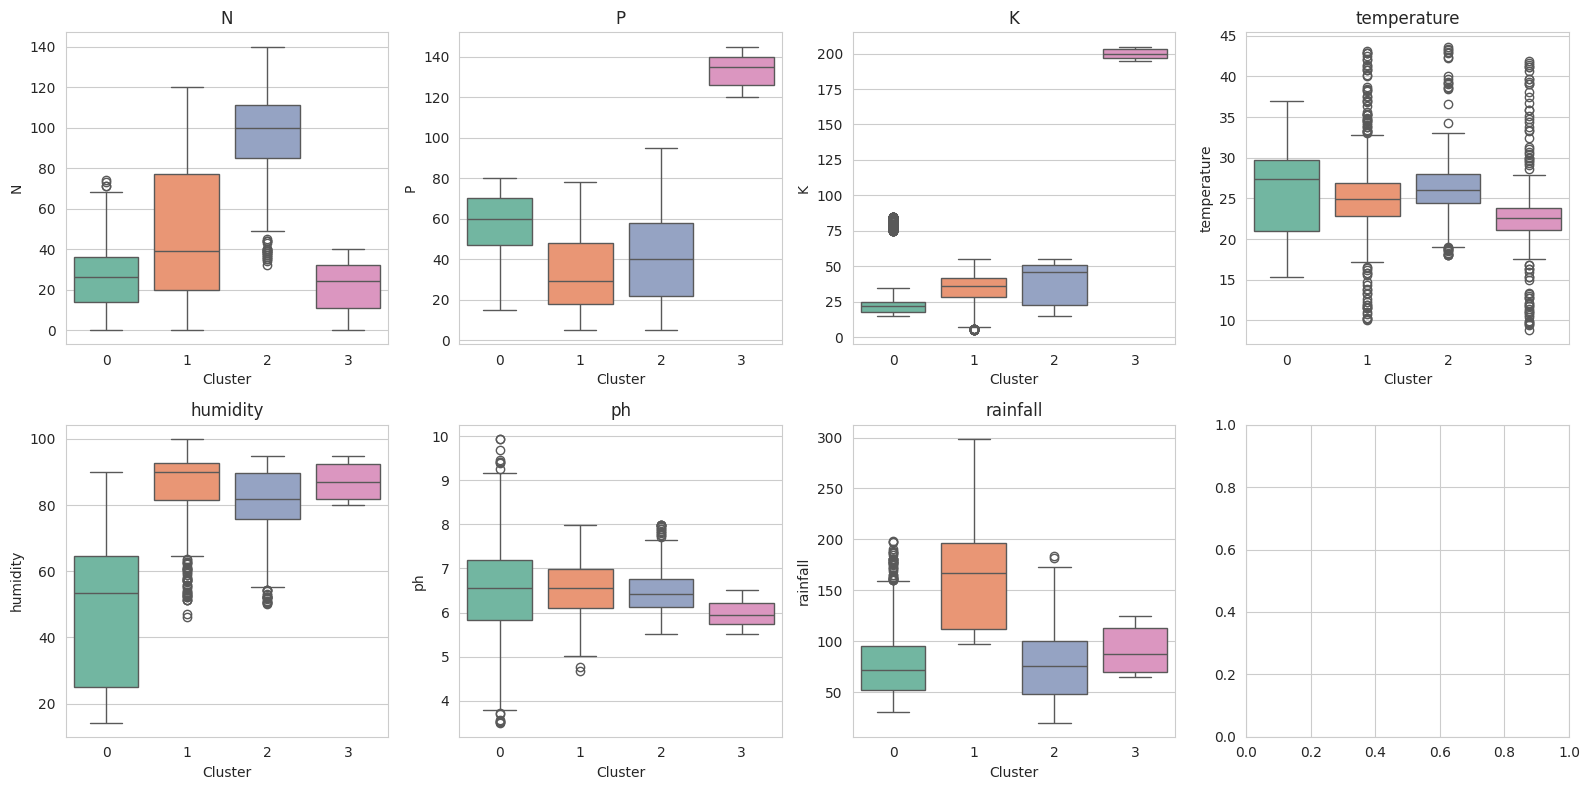

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), feature_cols):
    sns.boxplot(data=df, x='Cluster', y=col, hue='Cluster', palette='Set2', ax=ax, legend=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()


## 10. Recommendation Engine

Instead of hard-coding text, we generate recommendations dynamically from each cluster's own average
N, P, K, pH and rainfall values, compared against the overall dataset averages. This way the advice
automatically adapts if the dataset or number of clusters changes.


In [16]:
overall_mean = df[feature_cols].mean()

def generate_recommendation(cluster_id, profile_row):
    n, p, k = profile_row['N'], profile_row['P'], profile_row['K']
    temp, hum, ph, rain = profile_row['temperature'], profile_row['humidity'], profile_row['ph'], profile_row['rainfall']

    # --- Irrigation advice ---
    if rain < overall_mean['rainfall'] * 0.7:
        irrigation = "Low natural rainfall — set up regular drip or sprinkler irrigation; monitor soil moisture closely."
    elif rain > overall_mean['rainfall'] * 1.3:
        irrigation = "High natural rainfall — focus on drainage; irrigate only during dry spells to avoid waterlogging."
    else:
        irrigation = "Moderate rainfall — supplement with irrigation during dry periods, especially at flowering/fruiting stages."

    # --- Fertilizer suggestion ---
    fert_notes = []
    if n < overall_mean['N'] * 0.8:
        fert_notes.append("nitrogen-rich fertilizer (e.g. urea, compost)")
    if p < overall_mean['P'] * 0.8:
        fert_notes.append("phosphorus supplement (e.g. DAP, rock phosphate)")
    if k < overall_mean['K'] * 0.8:
        fert_notes.append("potassium supplement (e.g. MOP)")
    if not fert_notes:
        fertilizer = "N-P-K levels are already close to or above average — maintain with balanced NPK fertilizer at standard dosage."
    else:
        fertilizer = "Apply " + ", ".join(fert_notes) + " to correct the below-average nutrient(s)."

    # --- Soil management tips ---
    if ph < 6.0:
        soil_tip = f"Soil is acidic (avg pH {ph:.1f}) — consider liming to raise pH toward neutral."
    elif ph > 7.5:
        soil_tip = f"Soil is alkaline (avg pH {ph:.1f}) — add organic matter or sulfur-based amendments to lower pH."
    else:
        soil_tip = f"Soil pH (avg {ph:.1f}) is in a healthy neutral range — maintain with regular organic matter addition."

    return {
        "Cluster": cluster_id,
        "Irrigation Advice": irrigation,
        "Fertilizer Suggestion": fertilizer,
        "Soil Management Tip": soil_tip
    }

recommendations = {}
for c in sorted(df['Cluster'].unique()):
    row = cluster_profile.loc[c]
    recommendations[c] = generate_recommendation(c, row)

for c, rec in recommendations.items():
    print(f"--- Cluster {c} ({cluster_profile.loc[c, 'num_farmers']} farmers) ---")
    for k_, v_ in rec.items():
        if k_ != 'Cluster':
            print(f"  {k_}: {v_}")
    print()


--- Cluster 0 (797 farmers) ---
  Irrigation Advice: Moderate rainfall — supplement with irrigation during dry periods, especially at flowering/fruiting stages.
  Fertilizer Suggestion: Apply nitrogen-rich fertilizer (e.g. urea, compost), potassium supplement (e.g. MOP) to correct the below-average nutrient(s).
  Soil Management Tip: Soil pH (avg 6.5) is in a healthy neutral range — maintain with regular organic matter addition.

--- Cluster 1 (618 farmers) ---
  Irrigation Advice: High natural rainfall — focus on drainage; irrigate only during dry spells to avoid waterlogging.
  Fertilizer Suggestion: Apply phosphorus supplement (e.g. DAP, rock phosphate), potassium supplement (e.g. MOP) to correct the below-average nutrient(s).
  Soil Management Tip: Soil pH (avg 6.5) is in a healthy neutral range — maintain with regular organic matter addition.

--- Cluster 2 (585 farmers) ---
  Irrigation Advice: Moderate rainfall — supplement with irrigation during dry periods, especially at flowe

## 11. Predict the Cluster for a New Farmer (User Input)

Enter a new farmer's soil test and weather readings below. The app scales the input with the **same**
scaler fitted on the training data, predicts which cluster it belongs to, and returns the matching
recommendations.


In [17]:
def predict_new_farmer(N, P, K, temperature, humidity, ph, rainfall):
    new_data = pd.DataFrame([{
        'N': N, 'P': P, 'K': K,
        'temperature': temperature, 'humidity': humidity,
        'ph': ph, 'rainfall': rainfall
    }])
    new_scaled = scaler.transform(new_data[feature_cols])
    cluster_id = int(kmeans.predict(new_scaled)[0])
    rec = recommendations[cluster_id]

    print(f"Predicted Cluster: {cluster_id}")
    print(f"Similar to farmers commonly growing: "
          f"{list(df[df['Cluster']==cluster_id]['label'].value_counts().head(3).index)}")
    print()
    print("Recommendations:")
    print(f"  Irrigation Advice     : {rec['Irrigation Advice']}")
    print(f"  Fertilizer Suggestion : {rec['Fertilizer Suggestion']}")
    print(f"  Soil Management Tip   : {rec['Soil Management Tip']}")
    return cluster_id, rec


In [18]:
# Example: try it out with a sample farmer's soil/weather readings
# (Replace these numbers with any new farmer's real readings)
_ = predict_new_farmer(
    N=40, P=60, K=45,
    temperature=24.5, humidity=78,
    ph=6.4, rainfall=110
)


Predicted Cluster: 1
Similar to farmers commonly growing: ['rice', 'pomegranate', 'orange']

Recommendations:
  Irrigation Advice     : High natural rainfall — focus on drainage; irrigate only during dry spells to avoid waterlogging.
  Fertilizer Suggestion : Apply phosphorus supplement (e.g. DAP, rock phosphate), potassium supplement (e.g. MOP) to correct the below-average nutrient(s).
  Soil Management Tip   : Soil pH (avg 6.5) is in a healthy neutral range — maintain with regular organic matter addition.


### Interactive input (run in a local Jupyter/terminal environment)

The cell below uses Python's `input()` to collect values interactively. It's commented out here so the
notebook can run end-to-end automatically (e.g. via `nbconvert --execute`), but you can uncomment and run it
in your own Jupyter session to type in values by hand.


In [19]:
# Uncomment to use interactively:

# N = float(input("Nitrogen (N): "))
# P = float(input("Phosphorus (P): "))
# K = float(input("Potassium (K): "))
# temperature = float(input("Temperature (°C): "))
# humidity = float(input("Humidity (%): "))
# ph = float(input("Soil pH: "))
# rainfall = float(input("Rainfall (mm): "))
#
# predict_new_farmer(N, P, K, temperature, humidity, ph, rainfall)


## 12. Save the Model Artifacts (for the Streamlit/Flask app)

We save the fitted scaler, K-Means model, and cluster recommendations so the web app (see
`streamlit_app.py`, provided separately) can load them without retraining.


In [20]:
import pickle

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

with open('recommendations.pkl', 'wb') as f:
    pickle.dump(recommendations, f)

with open('cluster_top_crops.pkl', 'wb') as f:
    top_crops = {c: list(df[df['Cluster']==c]['label'].value_counts().head(3).index)
                 for c in sorted(df['Cluster'].unique())}
    pickle.dump(top_crops, f)

print("Saved: scaler.pkl, kmeans_model.pkl, recommendations.pkl, cluster_top_crops.pkl")


Saved: scaler.pkl, kmeans_model.pkl, recommendations.pkl, cluster_top_crops.pkl


## Summary

- Loaded and explored the Crop Recommendation dataset (2200 rows, 7 numeric features, 22 crop labels used only for interpretation).
- Verified there were no missing values.
- Scaled features with `StandardScaler`.
- Used the **Elbow Method** and **silhouette scores** to justify **K = 4**.
- Fitted K-Means, visualized clusters with PCA, and computed the final silhouette score.
- Profiled each cluster's average soil/weather conditions and generated **irrigation, fertilizer, and soil management** recommendations dynamically from those profiles.
- Built a `predict_new_farmer()` function so new soil/weather readings can be classified into a cluster and given matching advice.
- Saved the trained scaler/model/recommendations so they can be reused in the bonus Streamlit web app.
